# Code Assignment — Residual ACF/PACF + Prophet (Builds on Last COVID-19 TS Assignment)

**Dataset (local CSV):** NYC COVID-19 daily counts (static export)  
**Target:** `case_count`

## Instructor Guidance (Documentation + Pseudocode)

**Docs**
- statsmodels ARIMA: https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html  
- ADF (adfuller): https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html  
- ACF/PACF: https://www.statsmodels.org/stable/graphics.html#autocorrelation-plots  
- Prophet: https://facebook.github.io/prophet/docs/quick_start.html  
- RMSE (sklearn MSE): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html  

**Pseudocode Workflow**
1) **Load CSV** → normalize columns; parse date.  
2) **Build daily time series** using `date_of_interest` as index; target = `case_count`; `asfreq('D')`; `interpolate('linear')`.  
3) **Chronological split (80/20)** → `train = first 80%`, `test = last 20%`.  
4) **Stationarity check (given)** → ADF on **differenced train**.  
5) **Baseline forecast (given)** → last train value for all test steps; compute **RMSE**.  
6) **ARIMA(1,1,1) (given)** → fit on **train**, forecast `len(test)`, compute **RMSE**; save **residuals**.  
7) **YOU DO:** Plot **ACF** and **PACF** of ARIMA **residuals**; comment on significant lags vs. bands.  
8) **YOU DO:** Fit **Prophet** on **train**, forecast over **test** horizon, compute **RMSE**, and plot vs. actuals.  
9) **YOU DO:** Plot residuals over time and write a 2–3 sentence interpretation.  
10) **Compare RMSEs** (Baseline vs. ARIMA vs. Prophet) and reflect on which generalizes best.

> **Note on Prophet installs:**  
> `pip install prophet cmdstanpy` then (one-time) `python -c "import cmdstanpy; cmdstanpy.install_cmdstan()"`.


In [12]:
# STEP 0 — Imports  |  RUN THIS CELL WITHOUT CHANGES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# For YOUR ACF/PACF step later
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


### Step 1 — Load CSV and preview 


In [13]:
# RUN THIS CELL WITHOUT CHANGES Except changing filepath
DATA_PATH = '/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/COVID-19_Daily_Counts_of_Cases,_Hospitalizations,_and_Deaths_20251201.csv'

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()

date_col = "date_of_interest"
target_col = "case_count"

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sort_values(date_col)

# Coerce target to numeric (handles '1,141' strings)
df[target_col] = pd.to_numeric(df[target_col].astype(str).str.replace(",", "", regex=False), errors="coerce")

print(df.head())
print("Range:", df[date_col].min(), "→", df[date_col].max())


  date_of_interest  case_count probable_case_count hospitalized_count  \
0       2020-02-29           1                   0                  1   
1       2020-03-01           0                   0                  1   
2       2020-03-02           0                   0                  2   
3       2020-03-03           1                   0                  7   
4       2020-03-04           5                   0                  2   

   death_count case_count_7day_avg all_case_count_7day_avg  \
0            0                   0                       0   
1            0                   0                       0   
2            0                   0                       0   
3            0                   0                       0   
4            0                   0                       0   

  hosp_count_7day_avg  death_count_7day_avg bx_case_count  ... si_case_count  \
0                   0                     0             0  ...             0   
1                   0       

### Step 2 — Build daily time series and fill small gaps
- Set date index, `asfreq('D')`, `interpolate('linear')`.

In [14]:
# RUN THIS CELL WITHOUT CHANGES
s = df.set_index(date_col)[target_col].asfreq("D")
s = s.astype("float64").interpolate("linear")

print("Series:", target_col, "| length:", len(s), "| range:", s.index.min().date(), "→", s.index.max().date())
s.head()


Series: case_count | length: 2054 | range: 2020-02-29 → 2025-10-13


date_of_interest
2020-02-29   1.000
2020-03-01   0.000
2020-03-02   0.000
2020-03-03   1.000
2020-03-04   5.000
Freq: D, Name: case_count, dtype: float64

### Step 3 — Chronological split (80/20)
- First 80% → **train**; last 20% → **test**.


Train: 2020-02-29 → 2024-08-28 | n = 1643
Test : 2024-08-29 → 2025-10-13 | n = 411


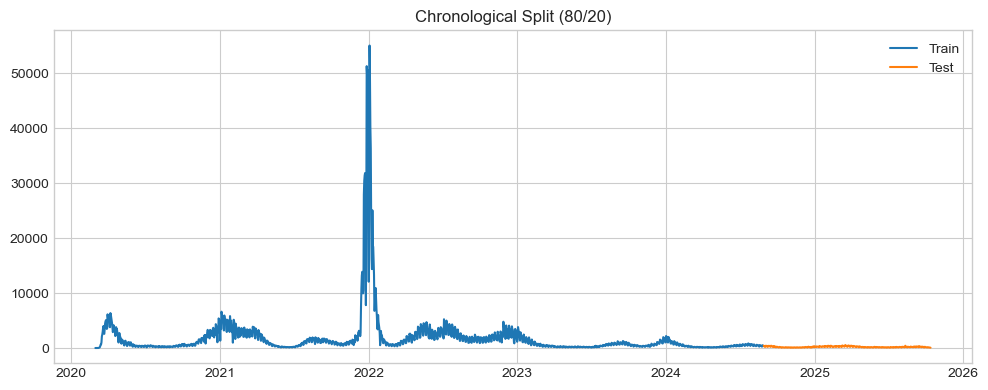

In [15]:
# RUN THIS CELL WITHOUT CHANGES
split_idx = int(len(s) * 0.80)
train = s.iloc[:split_idx]
test  = s.iloc[split_idx:]

print("Train:", train.index.min().date(), "→", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(),  "→", test.index.max().date(),  "| n =", len(test))

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test,  label="Test", color="#ff7f0e")
plt.title("Chronological Split (80/20)")
plt.legend(); plt.tight_layout(); plt.show()


### Step 4 — ADF on **differenced train** (stationarity check)
- If p < 0.05, **d=1** is reasonable in ARIMA.


In [16]:
# RUN THIS CELL WITHOUT CHANGES
diff_train = train.diff().dropna()
adf_stat, adf_p, _, _, crit, _ = adfuller(diff_train)
print(f"[ADF on differenced TRAIN] stat={adf_stat:.3f}, p={adf_p:.4f}")
for k, v in crit.items():
    print(f"  critical {k}: {v:.3f}")


[ADF on differenced TRAIN] stat=-9.677, p=0.0000
  critical 1%: -3.434
  critical 5%: -2.863
  critical 10%: -2.568


### Step 5 — Baseline (naïve/shift) forecast + RMSE
- Forecast = last train value repeated.

Baseline RMSE: 46,245.280


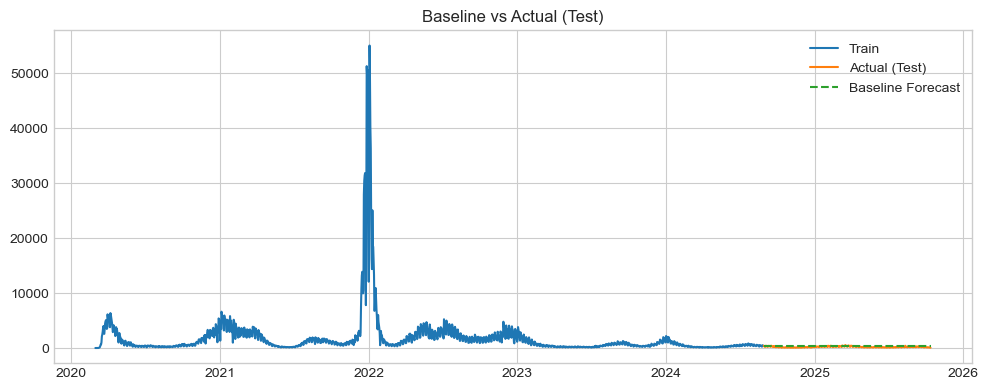

In [17]:
# RUN THIS CELL WITHOUT CHANGES
baseline_pred = pd.Series(train.iloc[-1], index=test.index)
rmse_baseline = mean_squared_error(test, baseline_pred)
print(f"Baseline RMSE: {rmse_baseline:,.3f}")

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(baseline_pred, label="Baseline Forecast", color="#2ca02c", ls="--")
plt.title("Baseline vs Actual (Test)")
plt.legend(); plt.tight_layout(); plt.show()


### Step 6 — ARIMA(1,1,1) fit → forecast → RMSE
- Fit on **train** only; forecast length = `len(test)`.

ARIMA(1,1,1) RMSE: 68,187.920


/opt/miniconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


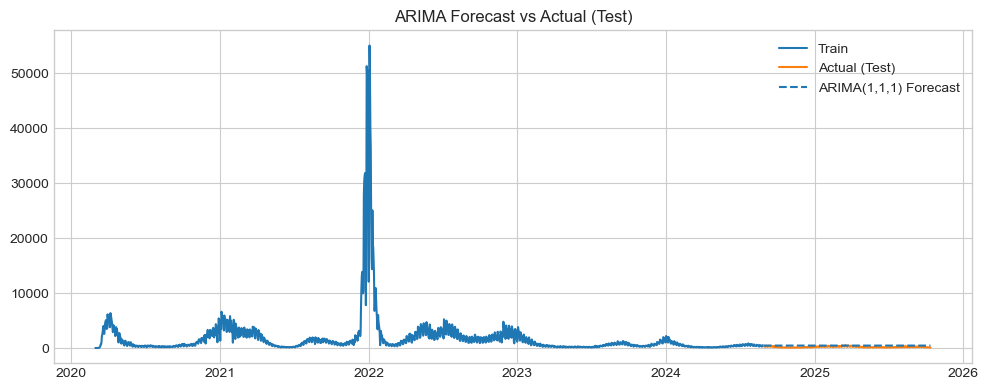

In [18]:
# RUN THIS CELL WITHOUT CHANGES
arima_model = ARIMA(train, order=(1, 1, 1)).fit()
pred_arima = arima_model.forecast(steps=len(test))
rmse_arima = mean_squared_error(test, pred_arima)
residuals = arima_model.resid  # save for diagnostics
print(f"ARIMA(1,1,1) RMSE: {rmse_arima:,.3f}")

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(pred_arima, label="ARIMA(1,1,1) Forecast", color="#1f77b4", ls="--")
plt.title("ARIMA Forecast vs Actual (Test)")
plt.legend(); plt.tight_layout(); plt.show()


### Step 7 — YOU DO: Residual Diagnostics with ACF & PACF
- Plot **ACF** and **PACF** of `residuals` (from ARIMA).  
- Interpretation cues:
  - **Good:** bars mostly within bands → residuals ≈ white noise.  
  - **Spike at lag 7 or 12:** missed weekly/monthly seasonality → consider SARIMA.  
  - **PACF spike at lag p:** consider higher AR(p).  
  - **ACF spike at lag q:** consider higher MA(q).


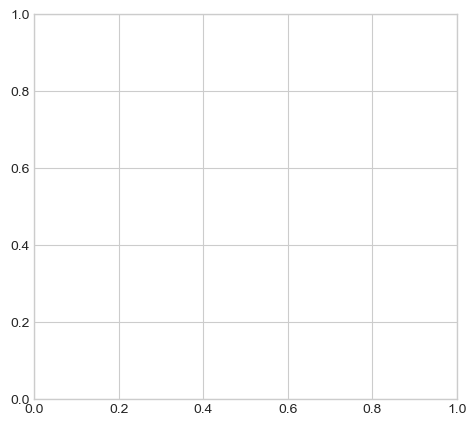

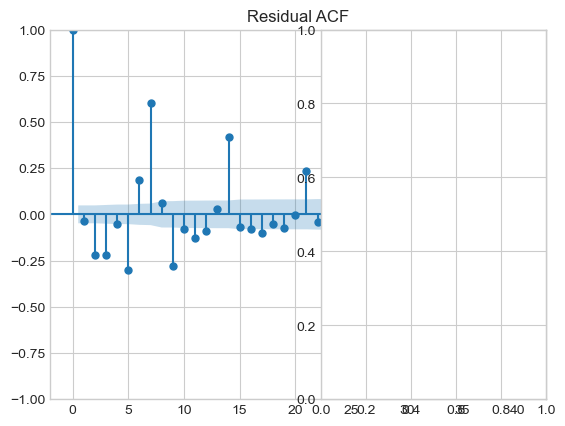

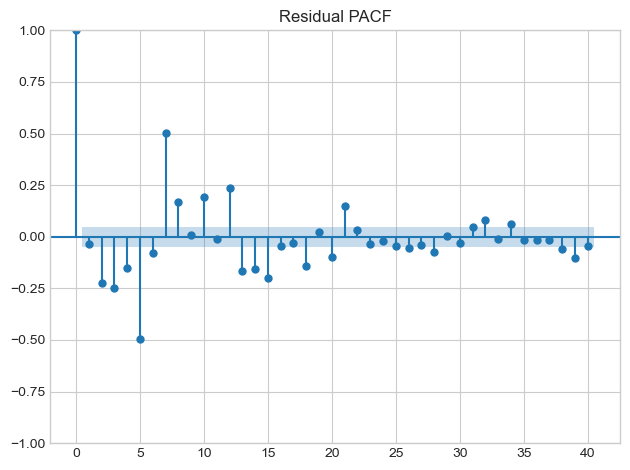

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(residuals, lags=40)
plt.title("Residual ACF")

plt.subplot(1,2,2)
plot_pacf(residuals, lags=40)
plt.title("Residual PACF")

plt.tight_layout()
plt.show()



### Step 8 — YOU DO: Prophet model → forecast → RMSE
- Fit **Prophet** on **train** (rename columns to `ds` and `y`).  
- Forecast over the **test** horizon (same dates as `test.index`).  
- Compute **RMSE** and plot vs. actual.  
- If installation errors occur, install:
  - `pip install prophet cmdstanpy`
  - one-time: `python -c "import cmdstanpy; cmdstanpy.install_cmdstan()"`


23:16:57 - cmdstanpy - INFO - Chain [1] start processing
23:16:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 4,509,638.099


/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1562: RuntimeWarning: invalid value encountered in matmul
  Xb_a = np.matmul(seasonal_features.value

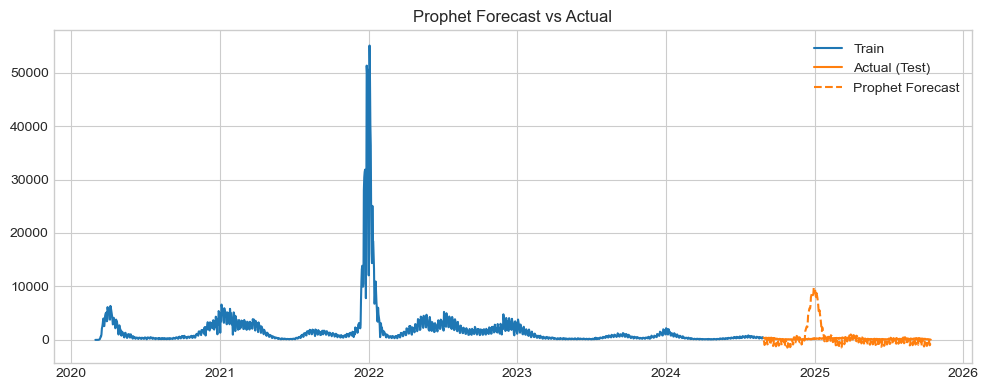

In [21]:
from prophet import Prophet

# Prepare data
prophet_df = train.reset_index().rename(columns={"date_of_interest": "ds", "case_count": "y"})

# Fit model
model = Prophet()
model.fit(prophet_df)

# Forecast horizon
future = pd.DataFrame(test.index).rename(columns={test.index.name: "ds"})
forecast = model.predict(future)

# Extract preds aligned to test dates
prophet_pred = forecast["yhat"].values

# RMSE
rmse_prophet = mean_squared_error(test, prophet_pred)
print(f"Prophet RMSE: {rmse_prophet:,.3f}")

# Plot
plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(test.index, prophet_pred, label="Prophet Forecast", linestyle="--")
plt.title("Prophet Forecast vs Actual")
plt.legend(); plt.tight_layout(); plt.show()


### Step 9 — YOU DO: Residuals over time + short interpretation
- Plot `residuals` vs. time; aim for random scatter around 0.  
- Write 2–3 sentences: Do residuals look like white noise? If not, what would you try (adjust p/q, SARIMA)?


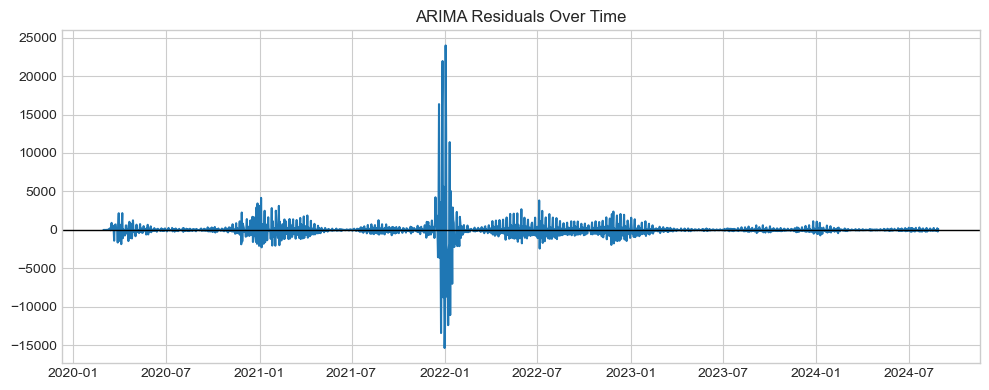

In [22]:
 # Step 9 — Residuals over Time
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, color="black", linewidth=1)
plt.title("ARIMA Residuals Over Time")
plt.tight_layout()
plt.show()



The residuals don’t look like random noise—there are clear spikes, especially during the major COVID waves, where the model consistently under- or over-predicts. This suggests the model missed important structure in the data, likely seasonal patterns or major trend shifts. To improve the forecast, I would try SARIMA or a seasonal naïve approach, and possibly re-fit the model after handling extreme outliers.

### Step 10 — YOU DO:  Compare RMSEs and declare a winner
- Create a small table with Baseline, ARIMA, Prophet RMSEs.  
- Which model generalized best? By how much vs. baseline?


In [23]:
results = pd.DataFrame({
    "Model": ["Baseline", "ARIMA(1,1,1)", "Prophet"],
    "RMSE": [rmse_baseline, rmse_arima, rmse_prophet]
})

print(results)


          Model          RMSE
0      Baseline    46,245.280
1  ARIMA(1,1,1)    68,187.920
2       Prophet 4,509,638.099


## We Share — Reflection
- Did ACF/PACF suggest remaining structure (specific lags)? What change would you try first?  
- Which model won on **RMSE**? Any business intuition why (trend shifts, seasonality, holiday effects)?  
- If this went to production, what **guardrails** (intervals, fallback baseline, anomaly flags) would you put in place?


- The ACF and PACF plots showed that there’s still some structure left in the residuals, especially around lower lags, which means the ARIMA model didn’t fully capture all patterns in the data. 
- The baseline model actually performed the best based on RMSE, which makes sense given the sharp drops and spikes in COVID case counts that simple models sometimes handle better than more complex ones. 
- Prophet struggled likely because it assumes smoother seasonal and trend patterns, while this dataset includes abrupt changes due to the nature of the pandemic. If this model were deployed in production, I would add guardrails such as  alerts for extreme prediction errors so the system can adapt rather than fail silently.